In [1]:
!pip install --upgrade seaborn
!pip install plotly

  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
  Attempting uninstall: seaborn
    Found existing installation: seaborn 0.12.0
    Uninstalling seaborn-0.12.0:
      Successfully uninstalled seaborn-0.12.0
  Using cached plotly-6.3.0-py3-none-any.whl (9.8 MB)
  Using cached narwhals-2.1.2-py3-none-any.whl (392 kB)


In [2]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import numpy as np
import pandas as pd

In [3]:
trip_data = pd.read_csv('./Data_saved/Only_trip/Vehicle2_clean_data_400epochs/Generated_data/EV_generated_data.csv')

In [4]:
# Remove duplicates
trip_data = trip_data.drop_duplicates()

# Print how many rows remain
print(f"Number of rows after removing duplicates: {len(trip_data)}")

trip_data['km_driven'] = trip_data['end_odo'] - trip_data['odo']
trip_data['discharge'] = trip_data['soc'] - trip_data['end_soc']

print("📊 Statistics on driven km:\n", trip_data['km_driven'].describe())
print("\n🔋 Statistics on discharge:\n", trip_data['discharge'].describe())

Number of rows after removing duplicates: 24
📊 Statistics on driven km:
 count     24.000000
mean     206.171577
std       49.606096
min       84.707692
25%      186.742354
50%      199.202629
75%      211.735316
max      327.220182
Name: km_driven, dtype: float64

🔋 Statistics on discharge:
 count    24.000000
mean      5.282313
std       1.103429
min       3.657620
25%       4.563146
50%       5.253774
75%       5.834104
max       8.073451
Name: discharge, dtype: float64


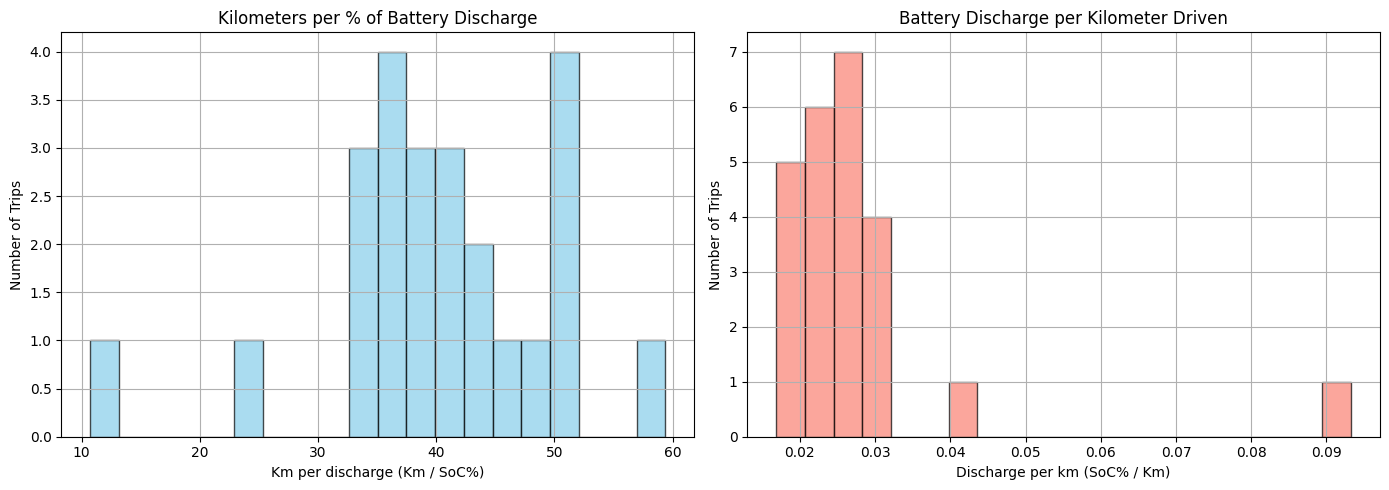

In [5]:
trip_data['km_per_perc_of_battery'] = trip_data.apply(
    lambda row: row['km_driven'] / row['discharge'] if row['discharge'] != 0 else 0,
    axis=1
)

trip_data['discharge_per_km'] = trip_data.apply(
    lambda row: row['discharge'] / row['km_driven'] if row['km_driven'] != 0 else 0,
    axis=1
)


# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kilometers per % battery
axes[0].hist(
    trip_data['km_per_perc_of_battery'],
    bins=20,
    alpha=0.7,
    color='skyblue',
    edgecolor='black'
)
axes[0].set_title('Kilometers per % of Battery Discharge')
axes[0].set_xlabel('Km per discharge (Km / SoC%)')
axes[0].set_ylabel('Number of Trips')
axes[0].grid(True)

# Discharge per km
axes[1].hist(
    trip_data['discharge_per_km'],
    bins=20,
    alpha=0.7,
    color='salmon',
    edgecolor='black'
)
axes[1].set_title('Battery Discharge per Kilometer Driven')
axes[1].set_xlabel('Discharge per km (SoC% / Km)')
axes[1].set_ylabel('Number of Trips')
axes[1].grid(True)

plt.tight_layout()
plt.show()

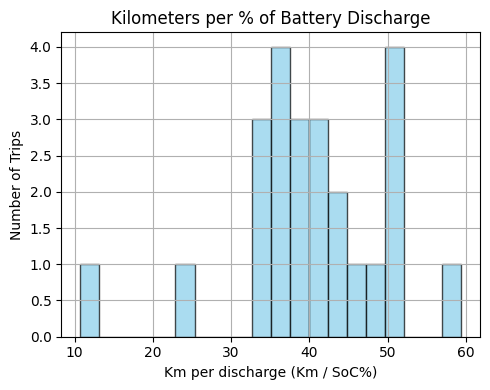

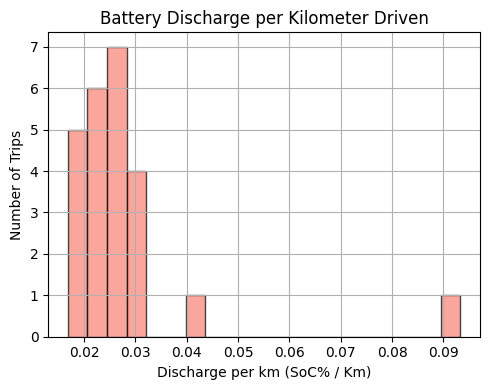

In [6]:
# Number of plots
n_models = 1  # only one dataset
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4), squeeze=False)

# First histogram
ax = axes[0, 0]
ax.hist(
    trip_data['km_per_perc_of_battery'],
    bins=20,
    color='skyblue',
    edgecolor='black',
    alpha=0.7
)
ax.set_title('Kilometers per % of Battery Discharge')
ax.set_xlabel('Km per discharge (Km / SoC%)')
ax.set_ylabel('Number of Trips')
ax.grid(True)

plt.tight_layout()
plt.show()

# Second histogram
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4), squeeze=False)

ax = axes[0, 0]
ax.hist(
    trip_data['discharge_per_km'],
    bins=20,
    color='salmon',
    edgecolor='black',
    alpha=0.7
)
ax.set_title('Battery Discharge per Kilometer Driven')
ax.set_xlabel('Discharge per km (SoC% / Km)')
ax.set_ylabel('Number of Trips')
ax.grid(True)

plt.tight_layout()
plt.show()


In [7]:
max_km = trip_data['km_per_perc_of_battery'].max()
max_km_row = trip_data[trip_data['km_per_perc_of_battery'] == max_km]

print("\n Row with maximum Km/SoC driven:\n")
max_km_row.head()


 Row with maximum Km/SoC driven:



,odo,end_odo,soc,end_soc,event,charge_mode,duration_minutes,km_driven,discharge,km_per_perc_of_battery,discharge_per_km
2,11490.151033,11801.432992,61.65476,56.41346,1.937783e-10,1.458678e-10,44.453395,311.28196,5.2413,59.390218,0.016838


In [8]:
outliers = trip_data[trip_data['km_per_perc_of_battery'] > 20].sort_values(by='km_per_perc_of_battery', ascending=False)
print(f'There are {len(outliers)} outliers')
outliers.head(len(outliers))

There are 23 outliers


,odo,end_odo,soc,end_soc,event,charge_mode,duration_minutes,km_driven,discharge,km_per_perc_of_battery,discharge_per_km
2,11490.151033,11801.432992,61.654760,56.413460,1.937783e-10,1.458678e-10,44.453395,311.281960,5.241300,59.390218,0.016838
19,11749.390475,11957.301631,61.312760,57.315873,1.944396e-10,1.500817e-10,42.703423,207.911156,3.996886,52.018283,0.019224
20,11745.453567,11947.308140,61.817456,57.861104,2.036405e-10,1.581977e-10,42.662489,201.854574,3.956352,51.020376,0.019600
21,11796.324809,11981.374377,62.092810,58.435190,2.186068e-10,1.707709e-10,41.644168,185.049568,3.657620,50.592886,0.019766
18,11753.224306,11964.369207,60.934501,56.724879,1.888703e-10,1.452944e-10,43.375251,211.144901,4.209622,50.157688,0.019937
17,11755.771326,11965.272201,60.727488,56.302267,1.852086e-10,1.421777e-10,44.030879,209.500875,4.425221,47.342470,0.021123
3,11404.047784,11680.626746,62.606249,56.643987,1.882030e-10,1.422418e-10,46.743866,276.578962,5.962262,46.388263,0.021557
16,11754.598234,11959.973349,60.645850,56.036730,1.827424e-10,1.400919e-10,44.533237,205.375115,4.609120,44.558418,0.022442
22,11868.022431,12032.805119,62.670539,58.815275,2.479776e-10,1.973495e-10,41.731061,164.782688,3.855263,42.742266,0.023396
15,11748.689546,11949.126772,60.637716,55.872138,1.810708e-10,1.386733e-10,44.903790,200.437226,4.765577,42.059378,0.023776


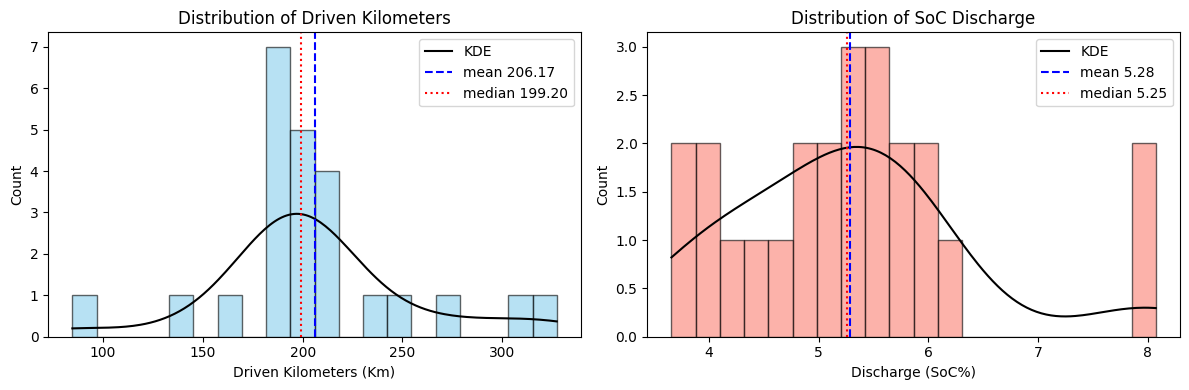

In [9]:
def plot_hist_with_kde(series, ax, color, title, xlabel, bins=20):
    # Ensure numeric and drop NaNs / infs
    y = pd.to_numeric(series, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna().values
    if y.size == 0:
        ax.text(0.5, 0.5, "No data", ha='center', va='center')
        ax.set_title(title)
        return

    # Histogram (counts)
    counts, bin_edges, _ = ax.hist(y, bins=bins, density=False,
                                   alpha=0.6, color=color, edgecolor='black')

    # KDE scaled to match histogram counts
    try:
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(y)
        x_grid = np.linspace(y.min(), y.max(), 200)
        # scale KDE to counts
        kde_vals = kde(x_grid) * len(y) * (bin_edges[1] - bin_edges[0])
        ax.plot(x_grid, kde_vals, color='k', lw=1.5, label='KDE')
    except ImportError:
        pass  # skip KDE if SciPy not available

    # Mean & median vertical lines
    ax.axvline(y.mean(), color='blue', linestyle='--', label=f'mean {y.mean():.2f}')
    ax.axvline(np.median(y), color='red', linestyle=':', label=f'median {np.median(y):.2f}')

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.legend()

# Usage example
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_hist_with_kde(trip_data.get('km_driven', pd.Series(dtype=float)), axes[0],
                   color='skyblue', title='Distribution of Driven Kilometers', xlabel='Driven Kilometers (Km)')

plot_hist_with_kde(trip_data.get('discharge', pd.Series(dtype=float)), axes[1],
                   color='salmon', title='Distribution of SoC Discharge', xlabel='Discharge (SoC%)')

plt.tight_layout()
plt.show()

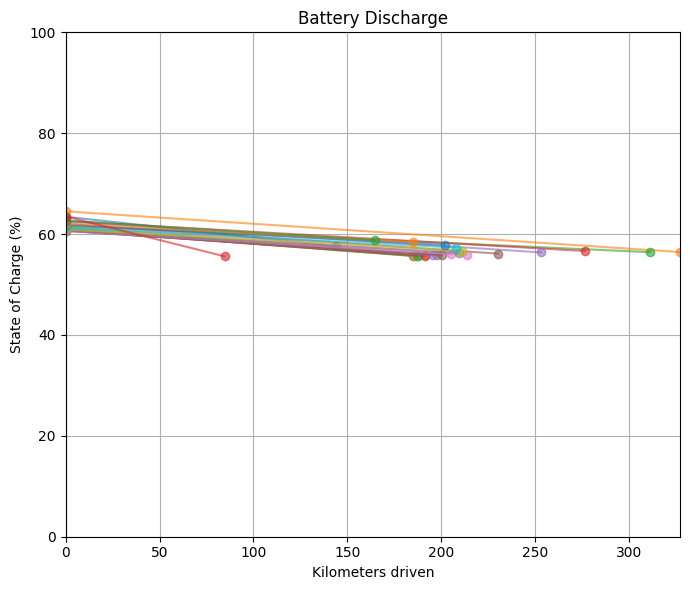

In [11]:
# Max km for x-axis scaling
max_km_driven = trip_data['km_driven'].max()

# --- Matplotlib version ---
fig, ax = plt.subplots(figsize=(7, 6))

for _, row in trip_data.iterrows():
    x_vals = [0, row['km_driven']]
    y_vals = [row['soc'], row['end_soc']]
    ax.plot(x_vals, y_vals, marker='o', alpha=0.6)

ax.set_title('Battery Discharge')
ax.set_xlabel('Kilometers driven')
ax.set_ylabel('State of Charge (%)')
ax.set_xlim(0, max_km_driven)
ax.set_ylim(0, 100)
ax.grid(True)

plt.tight_layout()
plt.show()


# --- Plotly version ---
colors = px.colors.qualitative.Plotly
fig = go.Figure()

for color_idx, (_, row) in enumerate(trip_data.reset_index().iterrows()):
    fig.add_trace(
        go.Scatter(
            x=[0, row['km_driven']],
            y=[row['soc'], row['end_soc']],
            mode='lines+markers',
            opacity=0.5,
            line=dict(color=colors[color_idx % len(colors)], width=2),
            marker=dict(size=6),
            name=f"Trip {row['index']}",
            hovertemplate=(
                f"Trip index: {row['index']}<br>"
                f"SOC start: {row['soc']}%<br>"
                f"SOC end: {row['end_soc']}%<br>"
                f"Km driven: {row['km_driven']} km<br>"
            )
        )
    )

fig.update_xaxes(title_text='Kilometers driven', range=[0, max_km_driven])
fig.update_yaxes(title_text='State of Charge (%)', range=[0, 100])

fig.update_layout(
    title="Battery Discharge",
    height=500,
    width=700,
    showlegend=False,
    hovermode='closest'
)

fig.show()
